<a href="https://colab.research.google.com/github/mimrancomsats/ProgrammingforAI_FALL25/blob/main/Lab_6_EDA%2BSklearn_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Preparation

*   Feature Scaling
*   Feature Binning
*   Column Transformer
*   Function Transfoerm
*   Sklearn Pipeline

In [1]:
!pip install ydata-profiling
import pandas as pd
from ydata_profiling import ProfileReport

df=pd.read_csv('titanic.csv')

prof = ProfileReport(df)
prof.to_file(output_file='eda.html')


/tmp/ipykernel_8537/4174622758.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install data-profiling via `pip install data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 37.71it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.pipeline import Pipeline

In [3]:
titanic = pd.read_csv('titanic.csv')

**Feature Scaling**

In [4]:
#Select features for scaling
features_to_scale = ['Age', 'Fare']

In [5]:
# Handle missing values
# Fill missing values in 'Age' and 'Fare' with the median
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Fare'] = titanic['Fare'].fillna(titanic['Fare'].median())
#titanic['Age'].fillna(titanic['Age'].median(), inplace=True)
#titanic['Fare'].fillna(titanic['Fare'].median(), inplace=True)

In [6]:
#Apply MinMaxScaler to the selected features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(titanic[features_to_scale])
#print(scaled_features)
print(type(scaled_features))

<class 'numpy.ndarray'>


In [7]:

# Convert scaled features into a DataFrame
scaled_df = pd.DataFrame(scaled_features, columns=features_to_scale)
print(scaled_df)


          Age      Fare
0    0.452723  0.015282
1    0.617566  0.013663
2    0.815377  0.018909
3    0.353818  0.016908
4    0.287881  0.023984
..        ...       ...
413  0.353818  0.015713
414  0.512066  0.212559
415  0.505473  0.014151
416  0.353818  0.015713
417  0.353818  0.043640

[418 rows x 2 columns]


In [8]:
#Concatenate the scaled features back into the original DataFrame
print(titanic[features_to_scale])
titanic[features_to_scale] = scaled_df
print(titanic[features_to_scale])
print(type(titanic[features_to_scale]))

      Age      Fare
0    34.5    7.8292
1    47.0    7.0000
2    62.0    9.6875
3    27.0    8.6625
4    22.0   12.2875
..    ...       ...
413  27.0    8.0500
414  39.0  108.9000
415  38.5    7.2500
416  27.0    8.0500
417  27.0   22.3583

[418 rows x 2 columns]
          Age      Fare
0    0.452723  0.015282
1    0.617566  0.013663
2    0.815377  0.018909
3    0.353818  0.016908
4    0.287881  0.023984
..        ...       ...
413  0.353818  0.015713
414  0.512066  0.212559
415  0.505473  0.014151
416  0.353818  0.015713
417  0.353818  0.043640

[418 rows x 2 columns]
<class 'pandas.core.frame.DataFrame'>


In [9]:
# Step 6: Display the results
print("After MinMax Scaling:")
print(titanic.shape)
print(titanic.head())

After MinMax Scaling:
(418, 12)
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex       Age  SibSp  \
0                              Kelly, Mr. James    male  0.452723      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  0.617566      1   
2                     Myles, Mr. Thomas Francis    male  0.815377      0   
3                              Wirz, Mr. Albert    male  0.353818      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  0.287881      1   

   Parch   Ticket      Fare Cabin Embarked  
0      0   330911  0.015282   NaN        Q  
1      0   363272  0.013663   NaN        S  
2      0   240276  0.018909   NaN        Q  
3      0   315154  0.016908   NaN        S  
4      1  3101298  0.023984   NaN        S  


# **Feature Binning**

In [10]:
# Extract Title from Name
titanic['Title'] = titanic['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(titanic['Title'])

0          Mr
1         Mrs
2          Mr
3          Mr
4         Mrs
        ...  
413        Mr
414      Dona
415        Mr
416        Mr
417    Master
Name: Title, Length: 418, dtype: object


In [11]:
# Define title mapping dictionary
title_mapping = {
    'Mr': 'Mr', 'Mrs': 'Mrs', 'Miss': 'Miss', 'Master': 'Master',
    'Capt': 'Officer', 'Col': 'Officer', 'Major': 'Officer', 'Dr': 'Officer', 'Rev': 'Officer',
    'Countess': 'Royalty', 'Sir': 'Royalty', 'Lady': 'Royalty', 'Jonkheer': 'Royalty', 'Don': 'Royalty',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'
}
print(type(titanic['Title']))
# Map extracted titles to broader categories & handle unknown titles
titanic['Title_Group'] = titanic['Title'].map(title_mapping)
print(titanic)
#filtered_titanic = titanic[titanic['Title_Group'] == 'Other'].tail(100)
#print(filtered_titanic)

<class 'pandas.core.series.Series'>
     PassengerId  Survived  Pclass  \
0            892         0       3   
1            893         1       3   
2            894         0       2   
3            895         0       3   
4            896         1       3   
..           ...       ...     ...   
413         1305         0       3   
414         1306         1       1   
415         1307         0       3   
416         1308         0       3   
417         1309         0       3   

                                             Name     Sex       Age  SibSp  \
0                                Kelly, Mr. James    male  0.452723      0   
1                Wilkes, Mrs. James (Ellen Needs)  female  0.617566      1   
2                       Myles, Mr. Thomas Francis    male  0.815377      0   
3                                Wirz, Mr. Albert    male  0.353818      0   
4    Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  0.287881      1   
..                                     

In [12]:
# Drop the original 'Title' column (optional)
titanic.drop(columns=['Title'], inplace=True)
print(titanic.head())

# Encode the categorical feature using One-Hot Encoding (optional for ML models)
titanic = pd.get_dummies(titanic, columns=['Title_Group'],  dtype=int)

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex       Age  SibSp  \
0                              Kelly, Mr. James    male  0.452723      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  0.617566      1   
2                     Myles, Mr. Thomas Francis    male  0.815377      0   
3                              Wirz, Mr. Albert    male  0.353818      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  0.287881      1   

   Parch   Ticket      Fare Cabin Embarked Title_Group  
0      0   330911  0.015282   NaN        Q          Mr  
1      0   363272  0.013663   NaN        S         Mrs  
2      0   240276  0.018909   NaN        Q          Mr  
3      0   315154  0.016908   NaN        S          Mr  
4      1  3101298  0.023984   NaN        

In [13]:
# Display the updated dataset with new feature
print(titanic.head())
print(titanic.shape)

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex       Age  SibSp  \
0                              Kelly, Mr. James    male  0.452723      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  0.617566      1   
2                     Myles, Mr. Thomas Francis    male  0.815377      0   
3                              Wirz, Mr. Albert    male  0.353818      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  0.287881      1   

   Parch   Ticket      Fare Cabin Embarked  Title_Group_Master  \
0      0   330911  0.015282   NaN        Q                   0   
1      0   363272  0.013663   NaN        S                   0   
2      0   240276  0.018909   NaN        Q                   0   
3      0   315154  0.016908   NaN        S                   0

**Column Transformer**

In [14]:
# Sample DataFrame
data = pd.DataFrame({
    'Age': [22, None, 24, 22, None, 24],
    'Sex': ['male', 'female', 'female','male', 'female', 'female'],
    'Embarked': ['B', 'B', 'C', 'C', 'C','S'],
    'Fare': [7.25, 71.83, 8.05,7.25, 71.83, 8.05]
})

print("Original DataFrame:")
print(data)

# Define ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('age_imputer', SimpleImputer(strategy='mean'), ['Age']),
    ('ohe', OneHotEncoder(), ['Sex','Embarked'])
], remainder='passthrough')  # Pass through other columns like 'Fare'

# Transform the data
transformed_data = preprocessor.fit_transform(data)

# Output shape and transformed data
print("\nTransformed Data Shape:")
print(transformed_data.shape)
#print(type(transformed_data))


transformed_df = pd.DataFrame(transformed_data)
print("\nTransformed DataFrame:")
print(transformed_df)

Original DataFrame:
    Age     Sex Embarked   Fare
0  22.0    male        B   7.25
1   NaN  female        B  71.83
2  24.0  female        C   8.05
3  22.0    male        C   7.25
4   NaN  female        C  71.83
5  24.0  female        S   8.05

Transformed Data Shape:
(6, 7)

Transformed DataFrame:
      0    1    2    3    4    5      6
0  22.0  0.0  1.0  1.0  0.0  0.0   7.25
1  23.0  1.0  0.0  1.0  0.0  0.0  71.83
2  24.0  1.0  0.0  0.0  1.0  0.0   8.05
3  22.0  0.0  1.0  0.0  1.0  0.0   7.25
4  23.0  1.0  0.0  0.0  1.0  0.0  71.83
5  24.0  1.0  0.0  0.0  0.0  1.0   8.05


**Function Transfomer**

In [15]:
# Sample DataFrame
data = pd.DataFrame({
    'Age': [22, None, 24,22, None, 24],
    'Sex': ['male', 'female', 'female','male', 'female', 'female'],
    'Embarked': ['B', 'B', 'C', None, 'C','S'],
    'Fare': [7.25, 71.83, 8.05,7.25, 71.83, 8.05]
})

print("Original DataFrame:")
print(data)

# Custom function to impute 'Embarked'
def impute_embarked(X):
    X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])  # Fill missing values
    print(X['Embarked'])
    return X

# Define ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('age_imputer', SimpleImputer(strategy='mean'), ['Age']),
    ('embarked_imputer', FunctionTransformer(impute_embarked), ['Embarked']),
    ('ohe', OneHotEncoder(), ['Sex','Embarked'])
], remainder='passthrough')  # Pass through other columns like 'Fare'

# Transform the data
transformed_data = preprocessor.fit_transform(data)

# Output shape and transformed data
print("\nTransformed Data Shape:")
print(transformed_data.shape)
print(transformed_data)


transformed_df = pd.DataFrame(transformed_data)
print("\nTransformed DataFrame:")
print(transformed_df)


Original DataFrame:
    Age     Sex Embarked   Fare
0  22.0    male        B   7.25
1   NaN  female        B  71.83
2  24.0  female        C   8.05
3  22.0    male     None   7.25
4   NaN  female        C  71.83
5  24.0  female        S   8.05
0    B
1    B
2    C
3    B
4    C
5    S
Name: Embarked, dtype: object

Transformed Data Shape:
(6, 9)
[[22.0 'B' 0.0 1.0 1.0 0.0 0.0 0.0 7.25]
 [23.0 'B' 1.0 0.0 1.0 0.0 0.0 0.0 71.83]
 [24.0 'C' 1.0 0.0 0.0 1.0 0.0 0.0 8.05]
 [22.0 'B' 0.0 1.0 0.0 0.0 0.0 1.0 7.25]
 [23.0 'C' 1.0 0.0 0.0 1.0 0.0 0.0 71.83]
 [24.0 'S' 1.0 0.0 0.0 0.0 1.0 0.0 8.05]]

Transformed DataFrame:
      0  1    2    3    4    5    6    7      8
0  22.0  B  0.0  1.0  1.0  0.0  0.0  0.0   7.25
1  23.0  B  1.0  0.0  1.0  0.0  0.0  0.0  71.83
2  24.0  C  1.0  0.0  0.0  1.0  0.0  0.0   8.05
3  22.0  B  0.0  1.0  0.0  0.0  0.0  1.0   7.25
4  23.0  C  1.0  0.0  0.0  1.0  0.0  0.0  71.83
5  24.0  S  1.0  0.0  0.0  0.0  1.0  0.0   8.05


**Sklean Pipeline**

In [16]:
# Sample DataFrame
data = pd.DataFrame({
    'Age': [22, None, 24,22, None, 24],
    'Sex': ['male', 'female', 'female','male', 'female', 'female'],
    'Embarked': ['B', 'B', 'C', None, 'C','S'],
    'Fare': [7.25, 71.83, 8.05,7.25, 71.83, 8.05]
})

print("Original DataFrame:")
print(data)

# Custom function to impute 'Embarked'
def impute_embarked(X):
    X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])  # Fill missing values
    print (X['Embarked'])
    return X

preprocessor = ColumnTransformer(transformers=[
    ('age_imputer', SimpleImputer(strategy='mean'), ['Age']),
    ('embarked_encoder', Pipeline(steps=[
        ('imputer', FunctionTransformer(impute_embarked)),  # Impute Embarked first
        ('onehot', OneHotEncoder())  # Then apply OneHotEncoder
    ]), ['Embarked']),
    ('ohe', OneHotEncoder(), ['Sex'])
], remainder='passthrough')  # Pass through other columns like 'Fare'


# Transform the data
transformed_data = preprocessor.fit_transform(data)

# Output shape and transformed data
print("\nTransformed Data Shape:")
print(transformed_data.shape)
print(transformed_data)

transformed_df = pd.DataFrame(transformed_data)
print("\nTransformed DataFrame:")
print(transformed_df)


Original DataFrame:
    Age     Sex Embarked   Fare
0  22.0    male        B   7.25
1   NaN  female        B  71.83
2  24.0  female        C   8.05
3  22.0    male     None   7.25
4   NaN  female        C  71.83
5  24.0  female        S   8.05
0    B
1    B
2    C
3    B
4    C
5    S
Name: Embarked, dtype: object

Transformed Data Shape:
(6, 7)
[[22.    1.    0.    0.    0.    1.    7.25]
 [23.    1.    0.    0.    1.    0.   71.83]
 [24.    0.    1.    0.    1.    0.    8.05]
 [22.    1.    0.    0.    0.    1.    7.25]
 [23.    0.    1.    0.    1.    0.   71.83]
 [24.    0.    0.    1.    1.    0.    8.05]]

Transformed DataFrame:
      0    1    2    3    4    5      6
0  22.0  1.0  0.0  0.0  0.0  1.0   7.25
1  23.0  1.0  0.0  0.0  1.0  0.0  71.83
2  24.0  0.0  1.0  0.0  1.0  0.0   8.05
3  22.0  1.0  0.0  0.0  0.0  1.0   7.25
4  23.0  0.0  1.0  0.0  1.0  0.0  71.83
5  24.0  0.0  0.0  1.0  1.0  0.0   8.05


# Lab Task

**Apply Feature Creation preprocessing step on the Titanic dataset to create a Family Size feature which calculates Family Size for each Passenger using following Equation. FamilySize = SibSp + Parch + 1**

**Apply ColumnTransformer, FunctionTransformer and Sklearn Pipeline on the Titanic dataset.**

**Use ColumnTransformer, FunctionTransformer and Sklearn Pipeline features to preprocess the following dataset**

https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease

**Titanic Dataset**

In [17]:
# Load Data
import pandas as pd

df = pd.read_csv("titanic.csv")

In [18]:
# Feature Creation (Family Size)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

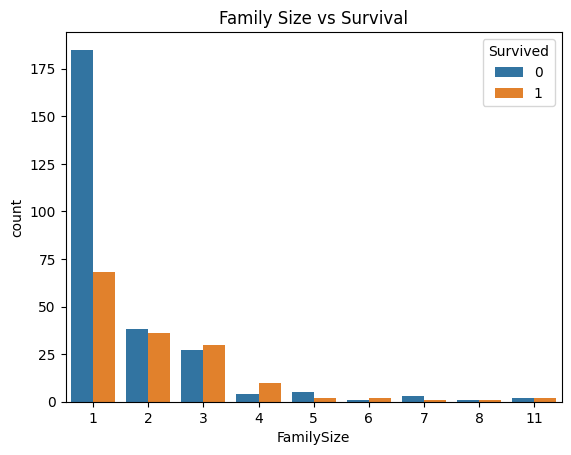

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualization
sns.countplot(x='FamilySize', hue='Survived', data=df)
plt.title("Family Size vs Survival")
plt.show()

In [34]:
# FunctionTransformer (Custom Feature)
from sklearn.preprocessing import FunctionTransformer

def add_family_size(X):
    X = X.copy()
    X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
    return X

family_transformer = FunctionTransformer(add_family_size)

In [21]:
# ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_cols = ['Age', 'Fare']
cat_cols = ['Sex', 'Embarked']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder())
    ]), cat_cols)
])

In [22]:
# Sklearn Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('family', family_transformer),
    ('preprocess', preprocessor),
    ('model', LogisticRegression())
])

In [23]:
# Run Pipeline
pipeline.fit(df, df['Survived'])

Pipeline(steps=[('family',
                 FunctionTransformer(func=<function add_family_size at 0x7885c0321f80>)),
                ('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  ['Sex', 'Embarked'])])),
                ('model', LogisticRegression())])

In [24]:
# See Transformed Data (before model)
X_transformed = pipeline.named_steps['preprocess'].fit_transform(df)

print(X_transformed)

[[ 0.38623105 -0.49741333  0.         ...  0.          1.
   0.        ]
 [ 1.37137004 -0.51227801  1.         ...  0.          0.
   1.        ]
 [ 2.55353683 -0.46410047  0.         ...  0.          1.
   0.        ]
 ...
 [ 0.70147553 -0.50779638  0.         ...  0.          0.
   1.        ]
 [-0.20485235 -0.49345515  0.         ...  0.          0.
   1.        ]
 [-0.20485235 -0.23695704  0.         ...  1.          0.
   0.        ]]


In [25]:
# Check FamilySize Column
df = add_family_size(df)
print(df[['SibSp','Parch','FamilySize']])

     SibSp  Parch  FamilySize
0        0      0           1
1        1      0           2
2        0      0           1
3        0      0           1
4        1      1           3
..     ...    ...         ...
413      0      0           1
414      0      0           1
415      0      0           1
416      0      0           1
417      1      1           3

[418 rows x 3 columns]


**For Heart Dataset**

In [26]:
# Load Dataset
df = pd.read_csv("heart_disease.csv")

In [27]:
# FunctionTransformer
def health_index(X):
    X = X.copy()
    X['HealthIndex'] = X['PhysicalHealth'] + X['MentalHealth']
    return X

health_transformer = FunctionTransformer(health_index)

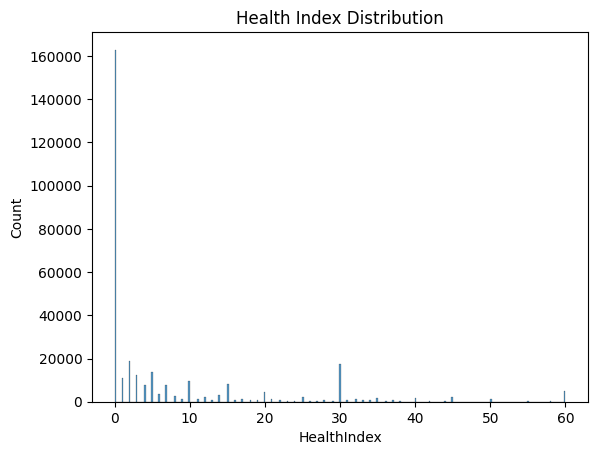

In [28]:
df['HealthIndex'] = df['PhysicalHealth'] + df['MentalHealth']

sns.histplot(df['HealthIndex'])
plt.title("Health Index Distribution")
plt.show()

In [29]:
# ColumnTransformer
num_cols = ['BMI','PhysicalHealth','MentalHealth','SleepTime']
cat_cols = ['Sex','Smoking','AgeCategory','GenHealth']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [30]:
# Pipeline
pipeline = Pipeline([
    ('feature', health_transformer),
    ('preprocess', preprocessor),
    ('model', LogisticRegression())
])

**Output**

In [31]:
pipeline.fit(df, df['HeartDisease'])

Pipeline(steps=[('feature',
                 FunctionTransformer(func=<function health_index at 0x7885c0384ae0>)),
                ('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['BMI', 'PhysicalHealth',
                                                   'MentalHealth',
                                                   'SleepTime']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Smoking',
                                                   'AgeCategory',
                                                   'GenHealth'])])),
                ('model', LogisticRegression())])

In [32]:
df = health_index(df)
print(df[['PhysicalHealth','MentalHealth','HealthIndex']])

        PhysicalHealth  MentalHealth  HealthIndex
0                  3.0          30.0         33.0
1                  0.0           0.0          0.0
2                 20.0          30.0         50.0
3                  0.0           0.0          0.0
4                 28.0           0.0         28.0
...                ...           ...          ...
319790             7.0           0.0          7.0
319791             0.0           0.0          0.0
319792             0.0           0.0          0.0
319793             0.0           0.0          0.0
319794             0.0           0.0          0.0

[319795 rows x 3 columns]


In [33]:
X_transformed = pipeline.named_steps['preprocess'].fit_transform(df)

print(X_transformed)

[[-1.84475016 -0.04675105  3.28106887 ...  0.          0.
   1.        ]
 [-1.25633812 -0.42406978 -0.49003859 ...  0.          0.
   1.        ]
 [-0.27460254  2.09138842  3.28106887 ...  0.          0.
   0.        ]
 ...
 [-0.64275338 -0.42406978 -0.49003859 ...  1.          0.
   0.        ]
 [ 0.70555975 -0.42406978 -0.49003859 ...  1.          0.
   0.        ]
 [ 2.86883929 -0.42406978 -0.49003859 ...  1.          0.
   0.        ]]
